# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
from keras.models import Sequential
import keras

### 1.1 Generating dataset

In [13]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [14]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [15]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [16]:
no_training_epochs = 5

### 1.3 Data examination

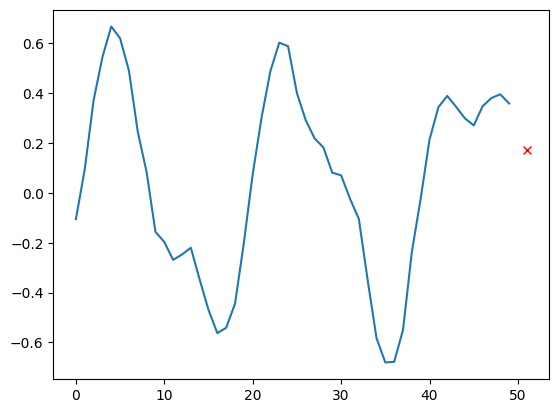

In [17]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [19]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
# Model building

learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [24]:
model_linear.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1572 - mean_squared_error: 0.1572 - val_loss: 0.0364 - val_mean_squared_error: 0.0364
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0268 - mean_squared_error: 0.0268 - val_loss: 0.0196 - val_mean_squared_error: 0.0196
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0180 - mean_squared_error: 0.0180 - val_loss: 0.0151 - val_mean_squared_error: 0.0151
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0150 - mean_squared_error: 0.0150 - val_loss: 0.0128 - val_mean_squared_error: 0.0128
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0132 - mean_squared_error: 0.0132 - val_loss: 0.0115 - val_mean_squared_error: 0.0115


In [26]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

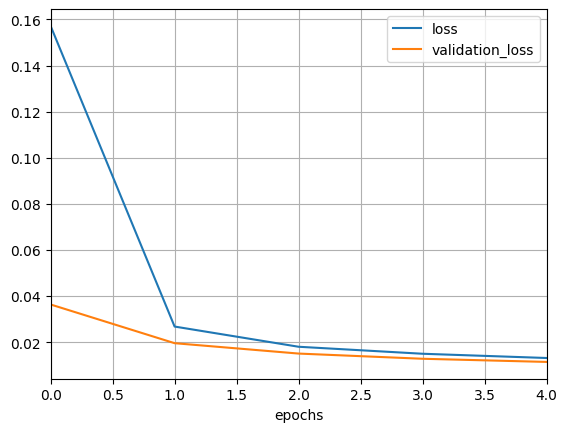

In [27]:
plot_function(history_linear)

In [28]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.01121657993644476
Test MSE:  0.01121657993644476


### 1.5 Simple RNN Model

In [29]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = keras.optimizers.Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [33]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.0265 - mean_squared_error: 1.0265 - val_loss: 1.0075 - val_mean_squared_error: 1.0075
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.8513 - mean_squared_error: 0.8513 - val_loss: 0.7836 - val_mean_squared_error: 0.7836
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6667 - mean_squared_error: 0.6667 - val_loss: 0.5924 - val_mean_squared_error: 0.5924
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.5058 - mean_squared_error: 0.5058 - val_loss: 0.5318 - val_mean_squared_error: 0.5318
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4660 - mean_squared_error: 0.4660 - val_loss: 0.4981 - val_mean_squared_error: 0.4981


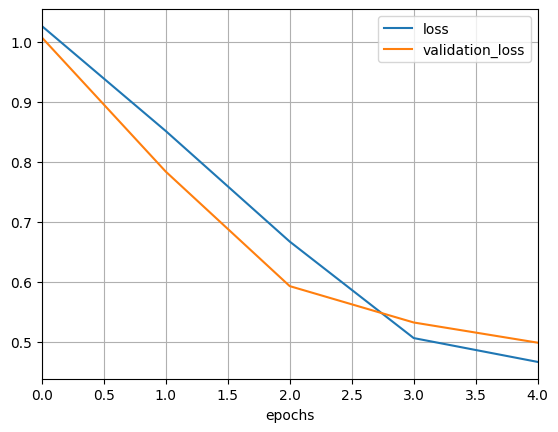

In [34]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [35]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = keras.optimizers.Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [38]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.0445 - mean_squared_error: 0.0445 - val_loss: 0.0113 - val_mean_squared_error: 0.0113
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0067 - mean_squared_error: 0.0067 - val_loss: 0.0054 - val_mean_squared_error: 0.0054
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0050 - mean_squared_error: 0.0050 - val_loss: 0.0054 - val_mean_squared_error: 0.0054
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0045 - mean_squared_error: 0.0045 - val_loss: 0.0048 - val_mean_squared_error: 0.0048
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0042 - mean_squared_error: 0.0042 - val_loss: 0.0039 - val_mean_squared_error: 0.0039


In [39]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.003782154293730855
Test MSE:  0.003782154293730855


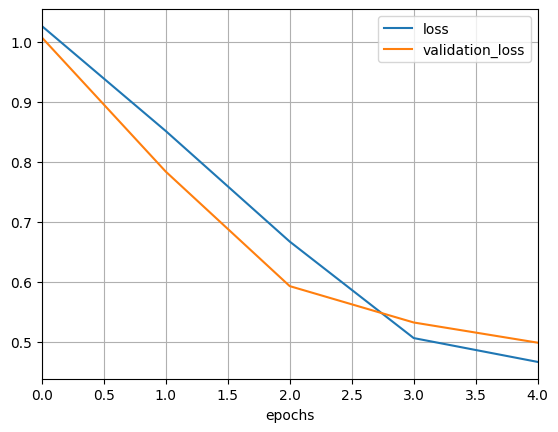

In [40]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [59]:
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [60]:
vocabulary_size = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)

### 2.2 - Dataset examination

In [61]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

In [56]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [57]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <unk> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <unk> to the two little boy's that played the <unk> of norman and paul they were just brilliant children are often left out of the <unk> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what

In [62]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [63]:
embed_size = 128

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
])

In [64]:
optimizer = Adam(learning_rate = 0.001)

In [65]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [66]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 135ms/step - accuracy: 0.5047 - loss: 0.7151 - val_accuracy: 0.4970 - val_loss: 0.6961
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 135ms/step - accuracy: 0.4994 - loss: 0.6953 - val_accuracy: 0.5062 - val_loss: 0.6984
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.4997 - loss: 0.6964 - val_accuracy: 0.4938 - val_loss: 0.6957
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.5026 - loss: 0.6958 - val_accuracy: 0.4950 - val_loss: 0.6954
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - accuracy: 0.4951 - loss: 0.6960 - val_accuracy: 0.4938 - val_loss: 0.6933


In [67]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6931843161582947
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 175s 277ms/step - accuracy: 0.5598 - loss: 0.6841 - val_accuracy: 0.5954 - val_loss: 0.6691
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 279ms/step - accuracy: 0.7564 - loss: 0.4966 - val_accuracy: 0.8490 - val_loss: 0.3591
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 173s 277ms/step - accuracy: 0.8996 - loss: 0.2555 - val_accuracy: 0.8588 - val_loss: 0.3363
LSTM -> Test loss: 0.3651, Test accuracy: 84.38%
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 220ms/step - accuracy: 0.5318 - loss: 0.6981 - val_accuracy: 0.5454 - val_loss: 0.6874
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 221ms/step - accuracy: 0.7924 - loss: 0.4364 - val_accuracy: 0.8578 - val_loss: 0.3370
Epoch 3/3
614/625 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.9246 - loss: 0.2059GRU -> Test loss: 0.3741, Test accuracy: 84.27%

Accuracy comparison:
SimpleRNN: 50.00%
LSTM: 84.38%
GRU: 84.27%


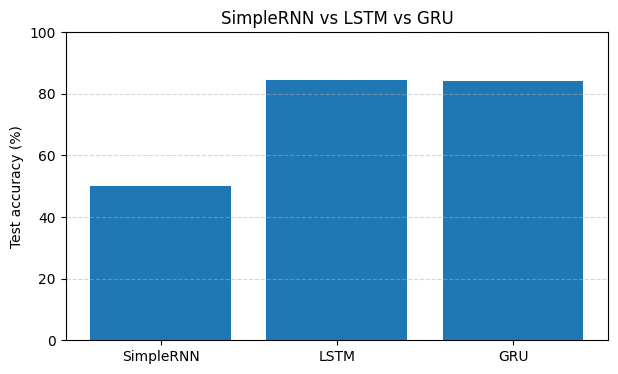

In [68]:
def build_text_model(recurrent_layer):
    return keras.models.Sequential([
        keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
        recurrent_layer,
        keras.layers.Dense(1, activation='sigmoid')
    ])


def train_and_evaluate(model_name, recurrent_layer, epochs=3):
    model_variant = build_text_model(recurrent_layer)
    model_variant.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    history_variant = model_variant.fit(
        X_train,
        y_train,
        epochs=epochs,
        validation_split=0.2,
        verbose=1
    )
    score_variant = model_variant.evaluate(X_test, y_test, verbose=0)
    print(f'{model_name} -> Test loss: {score_variant[0]:.4f}, Test accuracy: {score_variant[1] * 100:.2f}%')
    return history_variant, score_variant


history_lstm, score_lstm = train_and_evaluate('LSTM', keras.layers.LSTM(128), epochs=3)
history_gru, score_gru = train_and_evaluate('GRU', keras.layers.GRU(128), epochs=3)

comparison = {
    'SimpleRNN': score[1],
    'LSTM': score_lstm[1],
    'GRU': score_gru[1]
}

print('\nAccuracy comparison:')
for model_name, acc in comparison.items():
    print(f'{model_name}: {acc * 100:.2f}%')

plt.figure(figsize=(7, 4))
plt.bar(list(comparison.keys()), [v * 100 for v in comparison.values()])
plt.ylabel('Test accuracy (%)')
plt.title('SimpleRNN vs LSTM vs GRU')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()